In [10]:
from srcv2.utils import get_data_env
from srcv2.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from srcv2.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 2
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )    

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


In [11]:
dataorchestrator    = (DataOrchestrator(config).build())
shallowdata         = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
deepdata            = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()

target: incidence
Index(['timestamp', 'node', 'incidence', 'timestamp_sin', 'timestamp_cos',
       'incidence_lag0', 'train', 'val', 'test', 'target_ahead3',
       'target_ahead4'],
      dtype='object')


In [12]:
rf = NodeRFModel(shallowdata)

In [13]:
rf.set_global_hparams()
rf.set_model_hparams()
rf.train()

Training loss for horizon 0: RMSE = 0.6200, MAE = 0.2463
Validation loss for horizon 0: RMSE = 0.8374, MAE = 0.3672
Training loss for horizon 1: RMSE = 0.6928, MAE = 0.2795
Validation loss for horizon 1: RMSE = 0.9616, MAE = 0.4173


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

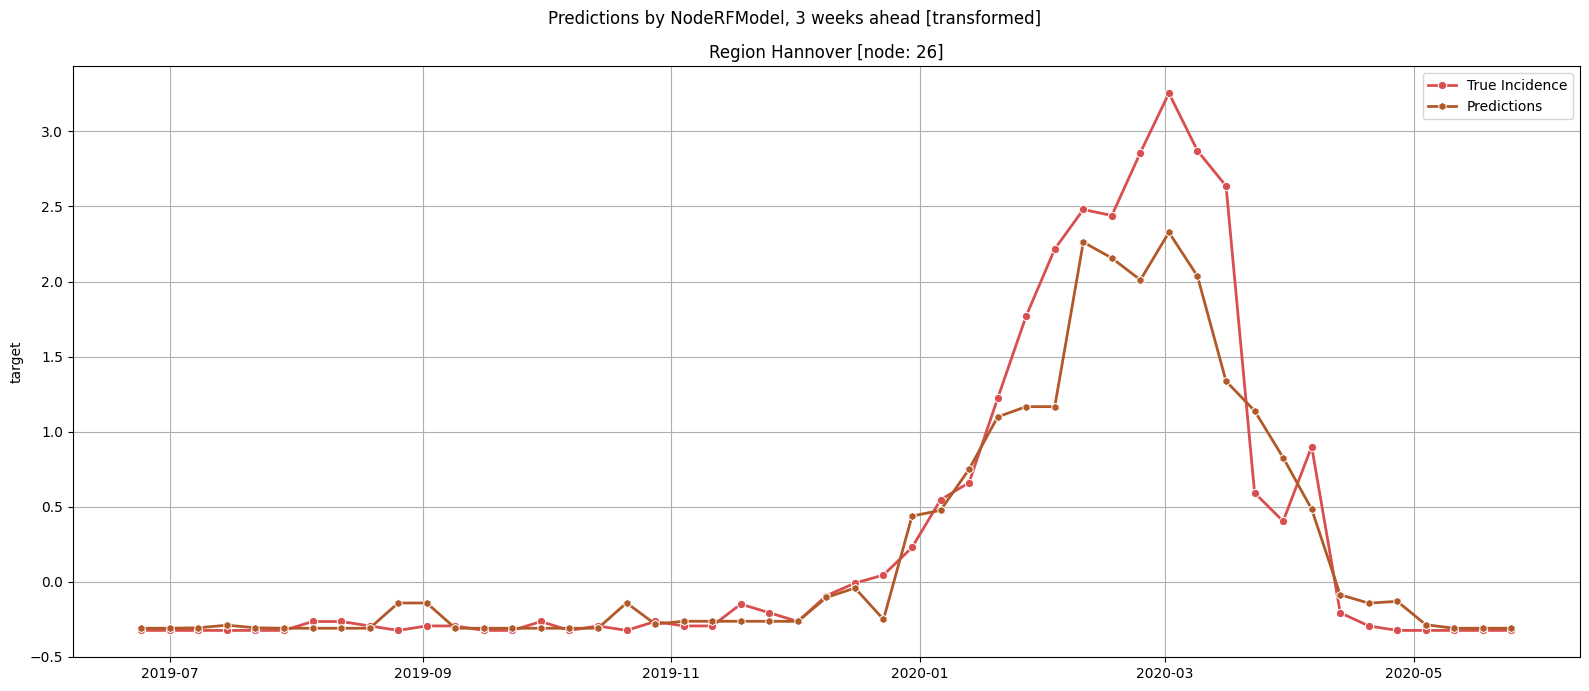

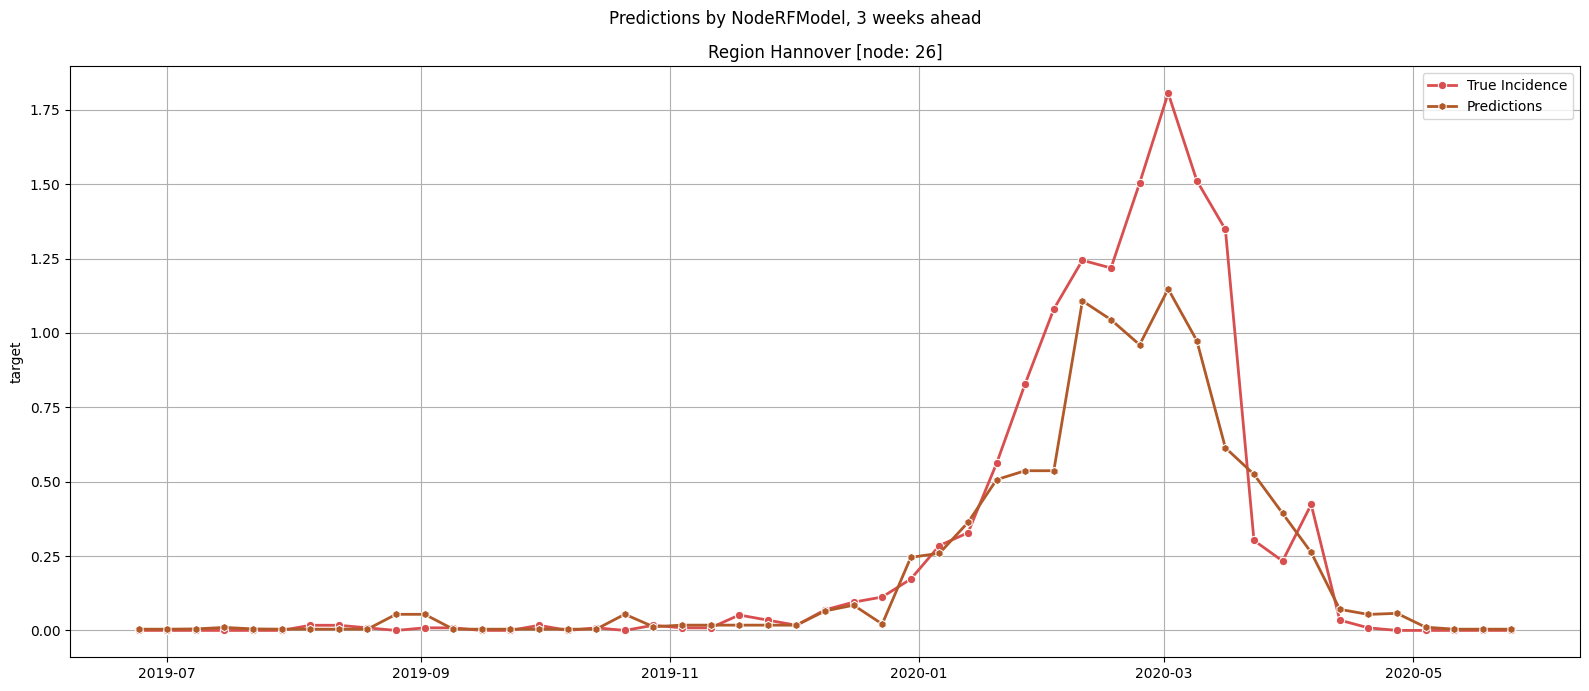

In [15]:
rf.forecast('test')
rf.show_forecasts(26,'test', transformed=True)
rf.show_forecasts(26,'test', transformed=False)

In [16]:
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()

In [17]:
lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 2)
lstm.forecast('test')
lstm.show_forecasts(26)


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.6942, val loss: 1.1030 ✓ (new best)
Epoch 2 train loss: 0.6807, val loss: 1.0211 ✓ (new best)
Epoch 3 train loss: 0.6676, val loss: 0.9479 ✓ (new best)
Epoch 4 train loss: 0.6602, val loss: 0.8658 ✓ (new best)
Epoch 5 train loss: 0.6529, val loss: 0.7994 ✓ (new best)
Epoch 6 train loss: 0.6434, val loss: 0.7455 ✓ (new best)
Epoch 7 train loss: 0.6393, val loss: 0.7289 ✓ (new best)


KeyboardInterrupt: 